# Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data

In [2]:
df_train = pd.read_csv("./data/train.csv")
df_test = pd.read_csv("./data/test.csv")

# Preprocessing

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

In [4]:
target_col = 'Depression'
id_col = 'id'

cat_cols = list(df_train.select_dtypes(include=['object', 'category']).columns)
num_cols = [col for col in df_train.columns if col not in (cat_cols + [target_col] + [id_col])]

cat_null_cols = [col for col in cat_cols if df_train[col].isnull().sum() > 0]
num_null_cols = [col for col in num_cols if df_train[col].isnull().sum() > 0]

one_hot_cols = [col for col in cat_cols if len(df_train[col].value_counts())!=2]
ordinal_cols = [col for col in cat_cols if len(df_train[col].value_counts())==2]

In [ ]:
ordinal_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))  
])

onehot_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('ordinal', OneHotEncoder(handle_unknown='ignore'))  
])

numerical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numerical_pipe, num_cols),
    ('cat_ordinal', ordinal_pipe, ordinal_cols),
    ('cat_onehot', onehot_pipe, one_hot_cols)
])

In [6]:
X = df_train.drop([id_col, target_col], axis=1)
y = df_train[target_col]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Hyperparameters tuning

In [7]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score
import optuna
import json

In [8]:
random_seed = 42

In [9]:
models = {
    'XGBClassifier': {
        'model': XGBClassifier,
        'params': {
            'n_estimators': ['int', 50, 500],
            'max_depth': ['int', 3, 10],
            'learning_rate': ['float', 0.01, 0.3],
            'subsample': ['float', 0.5, 1.0],
            'colsample_bytree': ['float', 0.5, 1.0],
            'gamma': ['float', 0, 5],
            'min_child_weight': ['int', 1, 10],
            'seed': ['other', random_seed]
        }
    },
    'LGBMClassifier': {
        'model': LGBMClassifier,
        'params': {
            'objective': ['categorical', ['binary']],
            'boosting_type': ['categorical', ['gbdt', 'dart']],
            'metric': ['categorical', ['binary_logloss']],
            'num_leaves': ['int', 15, 63],
            'learning_rate': ['float', 0.01, 0.3],
            'feature_fraction': ['float', 0.7, 1.0],
            'bagging_fraction': ['float', 0.5, 1.0],
            'bagging_freq': ['int', 1, 10],
            'verbosity': ['other', -1],
            'seed': ['other', random_seed]
        }
    },
    'CatBoostClassifier': {
        'model': CatBoostClassifier,
        'params': {
            'objective': ['categorical', ['Logloss', 'CrossEntropy']],
            'iterations': ['other', 100],
            'learning_rate': ['float', 0.01, 0.3],
            'depth': ['int', 3, 12],
            'l2_leaf_reg': ['float', 1.0, 10.0],
            'bagging_temperature': ['float', 0.0, 1.0],
            'grow_policy': ['categorical', ['SymmetricTree', 'Depthwise', 'Lossguide']],
            'verbose': ['other', False],
            'random_seed': ['other', random_seed]
        }
    }
}

In [10]:
current_MP = None

In [11]:
def objective(trial):
    model, params_raw = current_MP["model"], current_MP["params"]

    params = {}
    for key in params_raw.keys():
        if params_raw[key][0] == "int":
            params[key] = trial.suggest_int(key, params_raw[key][1], params_raw[key][2])
        elif params_raw[key][0] == "float":
            if key == "learning_rate":
                params[key] = trial.suggest_float(key, params_raw[key][1], params_raw[key][2], log=True)
            else:
                params[key] = trial.suggest_float(key, params_raw[key][1], params_raw[key][2])
        elif params_raw[key][0] == "categorical":
            params[key] = trial.suggest_categorical(key, params_raw[key][1])
        elif params_raw[key][0] == "other":
            params[key] = params_raw[key][1]

    model = model(**params)

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')
    return scores.mean()

In [ ]:
results = {}

for model in models.keys():
    current_MP = models[model]
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=100, show_progress_bar=True)

    results[model] = {
        "accuracy": study.best_value,
        "params": {
            **study.best_params,
            **{key:value[1] for key, value in models[model]["params"].items() if value[0] == 'other'}
        }
    }

    with open("./params/best_params.json", "w") as f:
        json.dump(results, f, indent=4)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

# Evaluation

In [10]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

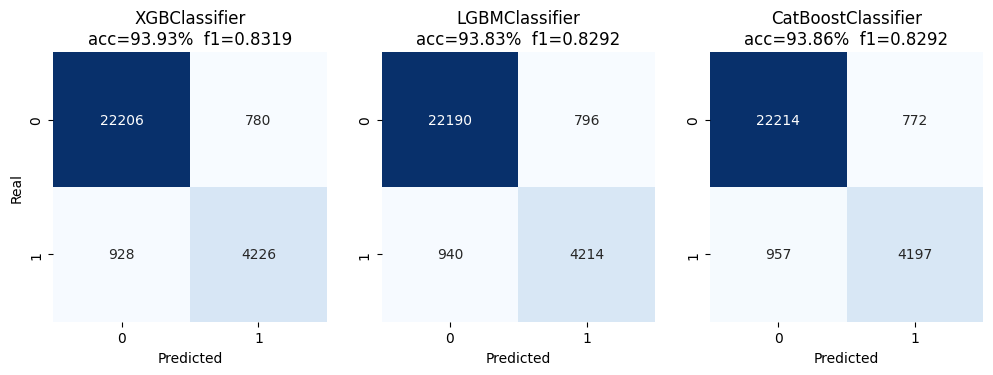

In [11]:
with open("./params/best_params.json", "r") as f:
    best_params = json.load(f)

n_models = len(best_params)
n_rows, n_cols = (n_models-1) // 3 + 1, min(n_models, 3)

fig, ax = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows))
for r in range(n_rows):
    for c in range(n_cols):
        current_ax = ax[r][c] if n_models > 3 else ax[c]
        
        model_name = list(best_params.keys())[3*r + c]
        params = best_params[model_name]["params"]
        model = models[model_name]["model"](**params)
        pipe = pipe = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_val)

        acc = accuracy_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred)
        conf_mtx = confusion_matrix(y_val, y_pred)

        sns.heatmap(conf_mtx, annot=True, cmap="Blues", fmt="g", ax=current_ax, cbar=False)
        
        current_ax.set_title(f"{model_name}\nacc={acc*100:.2f}%  f1={f1:.4f}")
        if c == 0:
            current_ax.set_ylabel("Real")
        if r + 1 == n_rows:
            current_ax.set_xlabel("Predicted")

plt.show()

# Save results

In [ ]:
final_model = XGBClassifier(**study.best_params)
final_pipe = pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', final_model)
])
final_pipe.fit(X, y)
pass

In [45]:
ids = df_test.id
X_test = df_test.drop(['id'],axis=1)
test_preds = final_pipe.predict(X_test)
submission = pd.DataFrame({
    'id': ids,
    'Depression': test_preds
})
submission.to_csv('submission.csv', index=False)